In [1]:
import torch
import numpy as np

from scripts.material_aware_training2 import material_aware_training2
from scripts.config import PathConfig, MaterialAwareTrainingConfig
from flare.dataset import DatasetLoader
from flame.FLAME import FLAME

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


/home/jsickert/miniconda3/envs/flare/lib/python3.9/site-packages/torch/utils/cpp_extension.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import packaging  # type: ignore[attr-defined]


In [2]:
device = torch.device('cpu')
if torch.cuda.is_available():
    device = torch.device(f"cuda:0")
print(f"Using device {device}")

Using device cuda:0


In [3]:
working_dir = "/home/jsickert/adl4cv"
run_name = "001"
input_dir = "DATA/001"
train_dir = ["MVI_1814", "MVI_1810"]
output_dir = "out"
flame_path = "/home/jsickert/adl4cv/adl4cv_ws25-26_Relightable-Avatars/flare/flame/FLAME2020/generic_model.pkl"
diffusion_dir = None
ghostbone = True
batch_size = 2
eval_dir = ["MVI_1812"]

args = PathConfig(
    _working_dir=working_dir,
    run_name=run_name,
    input_dir=input_dir,
    output_dir=output_dir,
    flame_path=flame_path,
    diffusion_dir=diffusion_dir,
    train_dir=train_dir,
    eval_dir=eval_dir,
)

In [4]:
training_config = MaterialAwareTrainingConfig.default_stage_1_config(batch_size=batch_size, ghostbone=ghostbone)

In [5]:
print("loading train views...")
dataset_train    = DatasetLoader(args, train_dir=args.train_dir, sample_ratio=1, pre_load=True)
dataset_val      = DatasetLoader(args, train_dir=args.eval_dir, sample_ratio=24, pre_load=True)
dataloader_train    = torch.utils.data.DataLoader(dataset_train, batch_size=batch_size, collate_fn=dataset_train.collate, shuffle=True, drop_last=True)
view_indices = np.array([15, 25, 27, 21, 26]).astype(int)
d_l = [dataset_val.__getitem__(idx) for idx in view_indices[2:]]
d_l.append(dataset_train.__getitem__(view_indices[0]))
d_l.append(dataset_train.__getitem__(view_indices[1]))
debug_views = dataset_val.collate(d_l)

loading train views...
loaded 2903 views
loaded 76 views


In [6]:
del dataset_val

In [7]:
flame_shape = dataset_train.shape_params
FLAMEServer = FLAME(flame_path, n_shape=100, n_exp=50, shape_params=flame_shape).to(device)
FLAMEServer.canonical_exp = (dataset_train.get_mean_expression()).to(device)
FLAMEServer.canonical_pose = FLAMEServer.canonical_pose.to(device)
FLAMEServer.canonical_verts, FLAMEServer.canonical_pose_feature, FLAMEServer.canonical_transformations = \
    FLAMEServer(expression_params=FLAMEServer.canonical_exp, full_pose=FLAMEServer.canonical_pose)
if ghostbone:
    FLAMEServer.canonical_transformations = torch.cat([torch.eye(4).unsqueeze(0).unsqueeze(0).float().to(device), FLAMEServer.canonical_transformations], 1)
FLAMEServer.canonical_verts = FLAMEServer.canonical_verts.to(device)

creating the FLAME Decoder


In [8]:
while True:
    try:
        material_aware_training2(training_config, args, device, dataset_train, dataloader_train, debug_views, FLAMEServer)
        break  # Exit the loop if main() runs successfully
    except:
        print("--"*50)
        print("Warning: Re-initializing main() because the training of light MLP diverged and all the values are zero. If the training does not restart, please end it and restart. ")
        print("--"*50)

Rasterizing: ['mask', 'position', 'normal', 'canonical_position']
Training Deformer
STAGE 1: Using positional encoding (NeRF) for intrinsic materials
{'material_mlp_ch': 5, 'light_mlp_ch': 3, 'material_mlp_dims': [128, 128, 128, 128], 'light_mlp_dims': [64, 64]}
{'mask': 2.0, 'normal': 0.1, 'laplacian': 60.0, 'shading': 1.0, 'perceptual_loss': 0.1, 'albedo_regularization': 0.01, 'roughness_regularization': 0.01, 'white_light_regularization': 0.01, 'fresnel_coeff': 0.01, 'flame_regularization': 1.0}
Batch Size: 2


Epoch 0, Iter 1:   0%|          | 0/2 [00:00<?, ?it/s]Using /home/jsickert/.cache/torch_extensions/py39_cu116 as PyTorch extensions root...
Detected CUDA files, patching ldflags
Emitting ninja build file /home/jsickert/.cache/torch_extensions/py39_cu116/renderutils_plugin/build.ninja...
Building extension module renderutils_plugin...
Allowing ninja to set a default number of workers... (overridable by setting the environment variable MAX_JOBS=N)


ninja: no work to do.


Loading extension module renderutils_plugin...
Epoch 0, Iter 101:   0%|          | 0/2 [00:31<?, ?it/s, loss=0.327]

Decaying flame regularization


Epoch 0, Iter 500:   0%|          | 0/2 [01:53<?, ?it/s, loss=0.254]

Upsampling at iteration: 500
Vertices: (17888, 3)
Faces: (35736, 3)
laplacian weight 240.0
normal consistency weight 0.4
lr vertices 0.00075


Epoch 1, Iter 2902: 100%|██████████| 2/2 [11:03<00:00, 331.91s/it, loss=0.0909]

TIME TAKEN (mins): 11


In [9]:
from scripts.flare_inference import build_flare_pipeline, run_inference, visualize_image_batch, visualize_image_buffers

In [10]:
dataset_val = DatasetLoader(args, train_dir=args.eval_dir, sample_ratio=1, pre_load=False)
dataloader_validate = torch.utils.data.DataLoader(dataset_val, batch_size=4, collate_fn=dataset_val.collate, shuffle=True)

In [20]:
mesh, FLAMEServer, deformer_net, shader, renderer, channels_gbuffer, lgt = build_flare_pipeline(
    dataset_val=dataset_val,
    flame_path=flame_path,
    mesh_path=args.working_dir / output_dir / run_name / "stage_1/meshes/mesh_latest.obj",
    deformer_path=args.working_dir / output_dir / run_name / "stage_1/network_weights/deformer_latest.pt",
    shader_path=args.working_dir / output_dir / run_name / "stage_1/network_weights/shader_latest.pt",
    train_dir=train_dir,
)

# mesh, FLAMEServer, deformer_net, shader, renderer, channels_gbuffer, lgt = build_flare_pipeline(
#     dataset_val=dataset_val,
#     flame_path="/home/jsickert/adl4cv/adl4cv_ws25-26_Relightable-Avatars/flare/flame/FLAME2020/generic_model.pkl",
#     mesh_path="/home/jsickert/adl4cv/MODELS/001/stage_1/meshes/mesh_latest.obj",
#     deformer_path="/home/jsickert/adl4cv/MODELS/001/stage_1/network_weights/deformer_latest.pt",
#     shader_path="/home/jsickert/adl4cv/MODELS/001/stage_1/network_weights/shader_latest.pt",
#     train_dir=train_dir,
# )

creating the FLAME Decoder


STAGE 1: Using positional encoding (NeRF) for intrinsic materials
{'material_mlp_ch': 5, 'light_mlp_ch': 3, 'material_mlp_dims': [128, 128, 128, 128], 'light_mlp_dims': [64, 64]}


In [21]:
for it, views in enumerate(dataloader_validate):
    break

print(views["frame_name"])

['295', '635', '147', '712']


In [17]:
rgb_pred, gbuffers, cbuffers = run_inference(views, mesh, FLAMEServer, deformer_net, shader, renderer, channels_gbuffer, lgt)

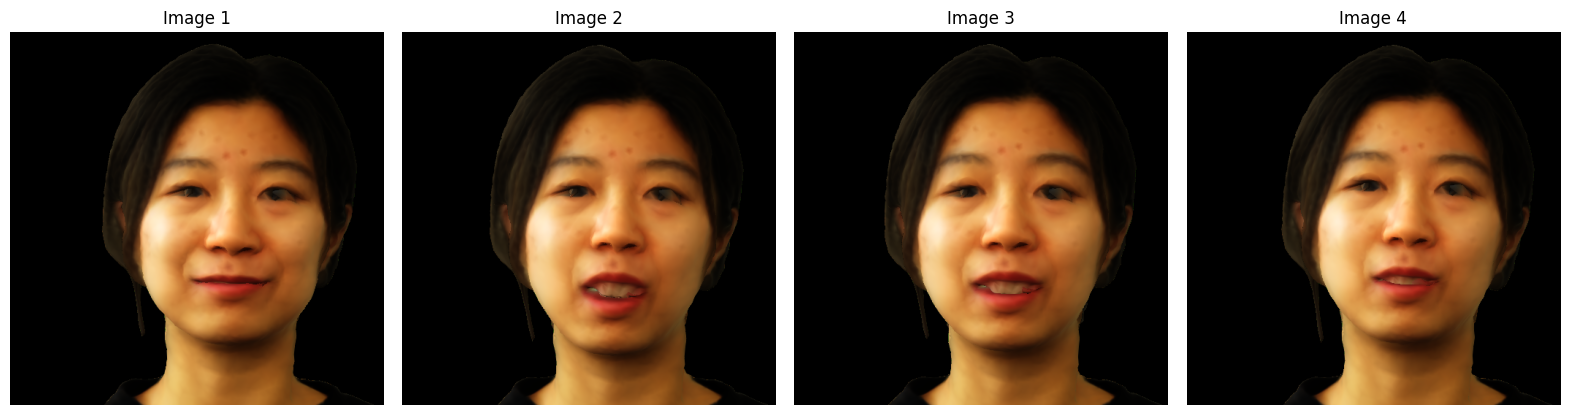

In [18]:
visualize_image_batch(rgb_pred)

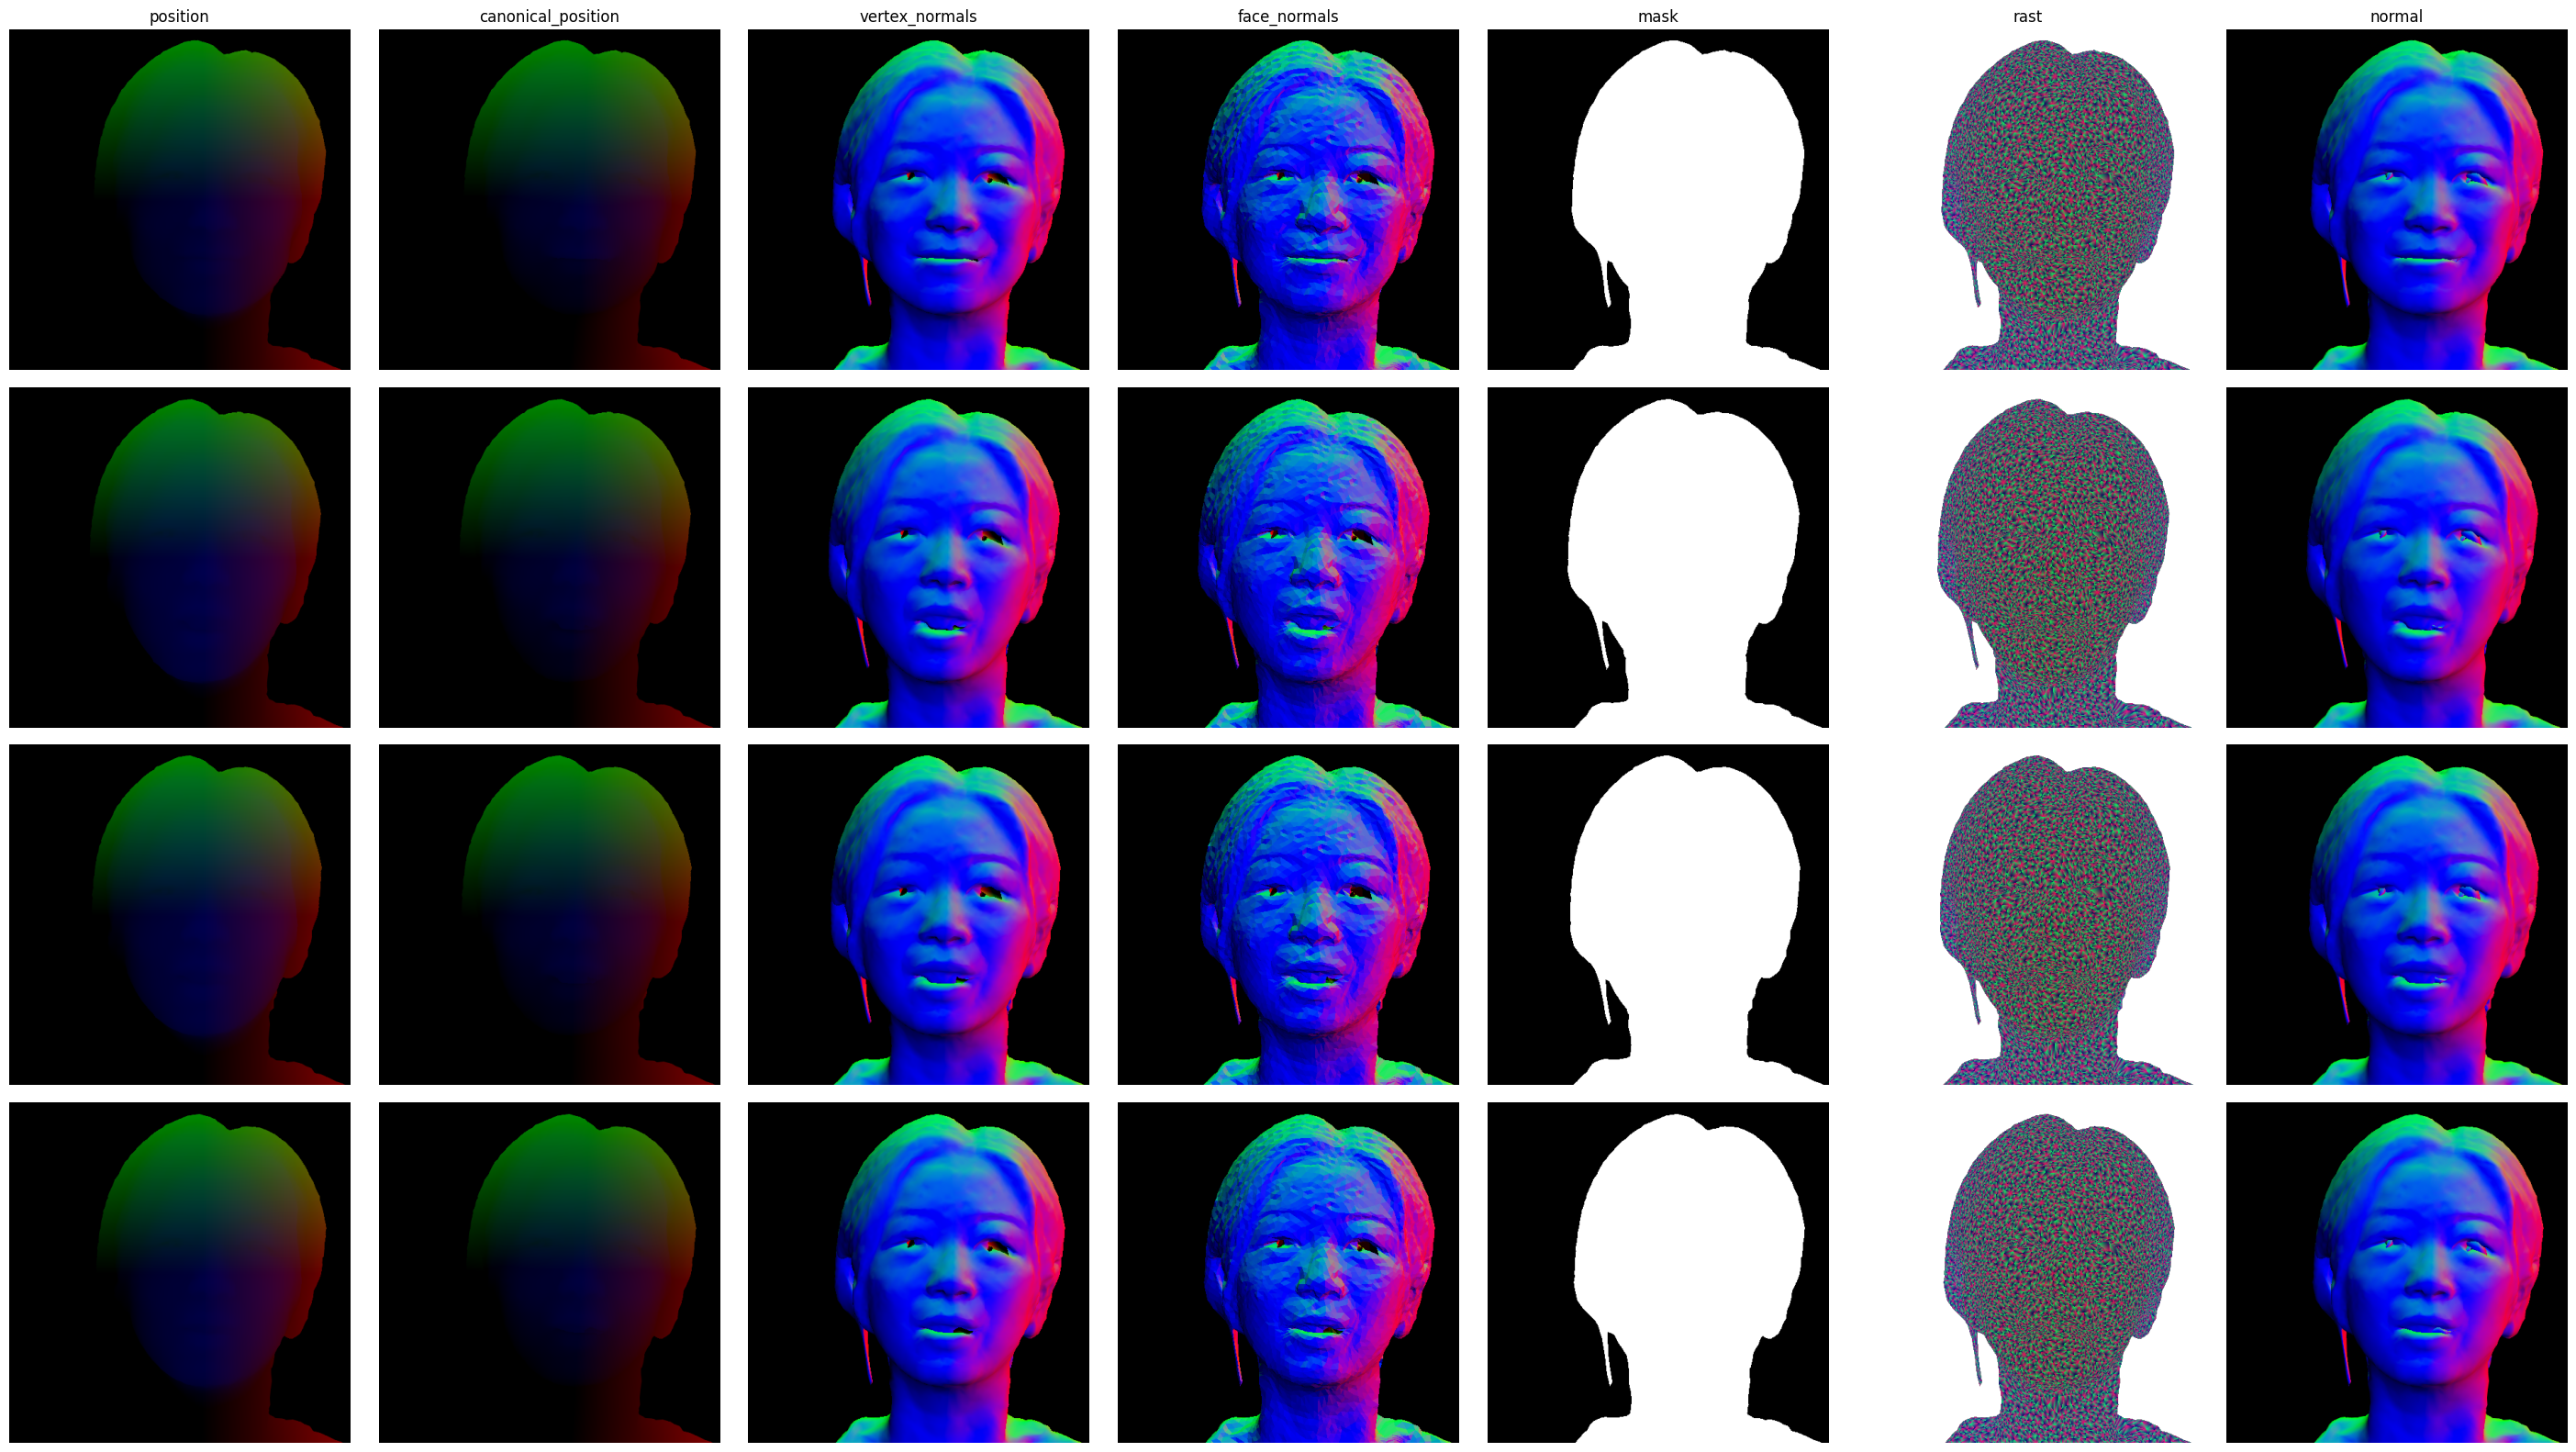

In [19]:
_gbuffers = {}
_gbuffers["position"] = gbuffers["position"]
_gbuffers["canonical_position"] = gbuffers["canonical_position"]
_gbuffers["vertex_normals"] = gbuffers["vertex_normals"]
_gbuffers["face_normals"] = gbuffers["face_normals"]
_gbuffers["mask"] = gbuffers["mask"]
_gbuffers["rast"] = gbuffers["rast"]
_gbuffers["normal"] = gbuffers["normal"]
visualize_image_buffers(_gbuffers)